In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from few.utils.mappings.kerrecceq import (apex_of_uwyz_nex,apex_of_uwyz, _uwyz_of_apex_kernel_nex , 
                                          _uwyz_of_apex_kernel , 
                                          kerrecceq_backward_map ,kerrecceq_backward_map_nex ,kerrecceq_forward_map,
                                            kerrecceq_forward_map_nex, a_of_z_nex, z_of_a_nex,
                                              AMIN_nex,AMAX_nex, p_of_u_flux,ALPHA_FLUX,BETA_FLUX,
                                                    p_of_u_flux_nex,u_of_p_flux_nex,
DELTAPMIN_REGIONC)
from multispline.spline import TricubicSpline
from few.utils.globals import get_file_manager

from few.trajectory.ode.flux import _PN_alt
from few.utils.geodesic import get_separatrix


In [4]:
10**(-1.625)

0.023713737056616554

## We can check that both models overlap on the overlap in parameter space between a $\in [0.99,0.999]$

In [1]:
fp = "KerrEccEqFluxData_nex.h5" 
file_path = fp  #fm.get_file(fp)      Need to update this to handle a proper filepath

with h5py.File(file_path, "r") as fluxData:
    regionA = fluxData["regionA"]
    u1 = np.linspace(0, 1, regionA.attrs["NU"])
    w1 = np.linspace(0, 1, regionA.attrs["NW"])
    z1 = np.linspace(0, 1, regionA.attrs["NZ"])

    ugrid, wgrid, zgrid = np.asarray(
        np.meshgrid(u1, w1, z1, indexing="ij")
    ).reshape(3, -1)
    agrid, pgrid, egrid, xgrid = apex_of_uwyz_nex(
        ugrid, wgrid, np.ones_like(zgrid), zgrid
    )

    # normalise by PN contribution
    Edot = regionA["Edot"][()]
    Ldot = regionA["Ldot"][()]


    Edot_interp_A_nex = TricubicSpline(u1, w1, z1, Edot )
    Ldot_interp_A_nex = TricubicSpline(u1, w1, z1, Ldot)


NameError: name 'h5py' is not defined

In [2]:
fp = "KerrEccEqFluxData.h5"

fm = get_file_manager()
file_path = fm.get_file(fp)

with h5py.File(file_path, "r") as fluxData:
    regionA = fluxData["regionA"]
    u2 = np.linspace(0, 1, regionA.attrs["NU"])
    w2 = np.linspace(0, 1, regionA.attrs["NW"])
    z2 = np.linspace(0, 1, regionA.attrs["NZ"])

    ugrid, wgrid, zgrid = np.asarray(
    np.meshgrid(u2, w2, z2, indexing="ij")
    ).reshape(3, -1)
    agrid, pgrid, egrid, xgrid = apex_of_uwyz(
    ugrid, wgrid, np.ones_like(zgrid), zgrid
    )

    # normalise by PN contribution
    Edot = regionA["Edot"][()]
    Ldot = regionA["Ldot"][()]



    Edot_interp_A = TricubicSpline(u2, w2, z2, Edot )
    Ldot_interp_A = TricubicSpline(u2, w2, z2, Ldot)



NameError: name 'get_file_manager' is not defined

### Test maps

In [5]:
#Test maps

a,  e, x = 0.999,0.2,1.0
pLSO = get_separatrix(a,e,x)
p=6

u,w,y,z = kerrecceq_forward_map_nex(a,p,e,x,pLSO,False)
uu,ww,yy,zz = kerrecceq_forward_map(a,p,e,x,pLSO,False)

print(kerrecceq_backward_map_nex(u,w,y,z))
kerrecceq_backward_map(uu,ww,yy,zz)


(array([0.999]), array([8.07034455]), array([0.2]), array([1.]))


(array([0.999]), array([6.]), array([0.2]), array([1.]))

In [6]:
p_of_u_flux_nex((u_of_p_flux_nex(6,pLSO)),pLSO)

6.000000000000006

In [7]:
Edot_interp_A_nex(u,w,z) , Edot_interp_A(uu,ww,zz)

(array([0.00634751]), array([0.00057904]))

In [8]:
a,  e, x = 0.99,0.0  ,1.0
pLSO = get_separatrix(a,e,x)

prange = np.linspace(pLSO, pLSO+8,100)
a,e,x = np.ones_like(prange)*a ,np.ones_like(prange)*e,np.ones_like(prange)

u,w,y,z = kerrecceq_forward_map_nex(a,prange,e,x,pLSO,False)
uu,ww,yy,zz = kerrecceq_forward_map(a,prange,e,x,pLSO,False)


#print(kerrecceq_backward_map_nex(u,w,y,z))
#print(kerrecceq_backward_map(uu,ww,yy,zz))


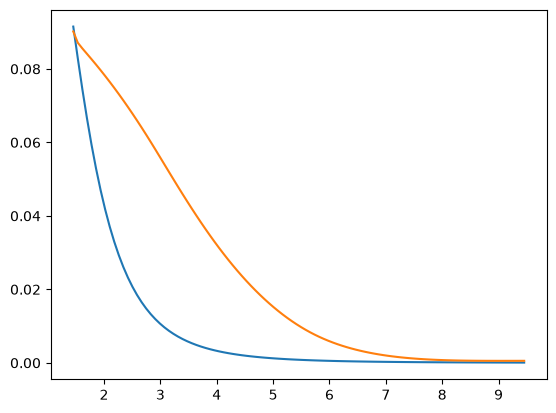

In [9]:
plt.plot(prange,Edot_interp_A(uu,ww,zz))
plt.plot(prange,Edot_interp_A_nex(u,w,z))

In [10]:
u

array([-0.05859508,  0.09073597,  0.14073319,  0.17688004,  0.20658323,
        0.23233056,  0.25532433,  0.27625542,  0.29556462,  0.31355378,
        0.33044047,  0.34638775,  0.36152163,  0.37594193,  0.38972935,
        0.40295026,  0.41566005,  0.42790553,  0.4397267 ,  0.45115807,
        0.46222964,  0.47296775,  0.48339562,  0.49353389,  0.50340097,
        0.5130134 ,  0.52238611,  0.5315326 ,  0.54046515,  0.54919496,
        0.55773231,  0.56608661,  0.57426655,  0.58228014,  0.59013481,
        0.59783746,  0.60539448,  0.61281186,  0.62009518,  0.62724967,
        0.63428022,  0.64119143,  0.64798764,  0.65467291,  0.66125108,
        0.6677258 ,  0.6741005 ,  0.68037842,  0.68656267,  0.69265615,
        0.69866166,  0.70458184,  0.71041922,  0.7161762 ,  0.72185506,
        0.72745801,  0.73298712,  0.73844441,  0.74383178,  0.74915108,
        0.75440405,  0.7595924 ,  0.76471773,  0.76978161,  0.77478553,
        0.77973093,  0.7846192 ,  0.78945166,  0.7942296 ,  0.79

Text(0.5, 1.0, '$\\dot{L}$ vs $(p-p_{sep})$, $e$= 0.25')

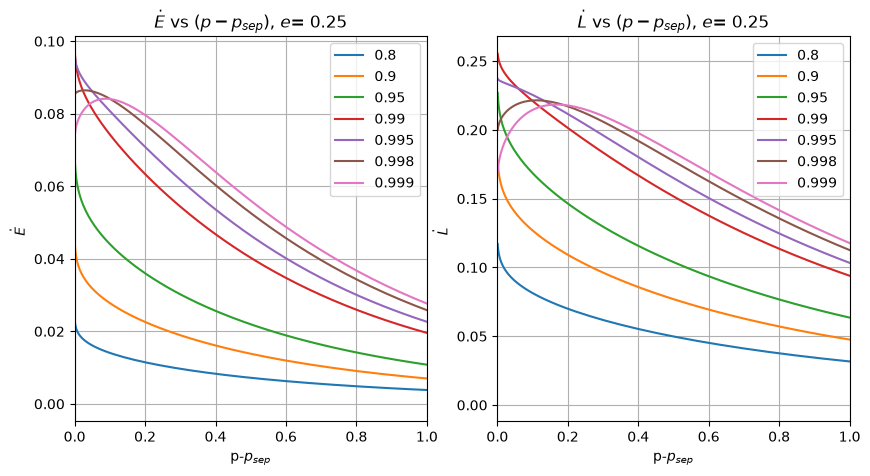

In [11]:
a_vals = [0.8,0.9,0.95,0.99,0.995,0.998,0.999]

with h5py.File(file_path, "r") as fluxData:
    regionA = fluxData["regionA"]

    u = np.linspace(0, 1, 129)
    w = np.linspace(0, 1,65)
    z = np.linspace(0, 1, 65)


    ugrid, wgrid, zgrid = np.asarray(
        np.meshgrid(u, w, z, indexing="ij")
    ).reshape(3, -1)
    agrid, pgrid, egrid, xgrid = apex_of_uwyz(
        ugrid, wgrid, np.ones_like(zgrid), zgrid, True
    )

fig,axs = plt.subplots(1,2,figsize=(10,5))

for aa in a_vals: 
    a,e,x = np.ones_like(u)*aa, np.ones_like(u)*0.25, np.ones_like(u)
    u,w,y,z = kerrecceq_forward_map(a, p_of_u_flux(u,get_separatrix(a,e,x)), e, x)

    axs[0].plot(
        (p_of_u_flux(u,get_separatrix(a,e,x))- get_separatrix(a,e,x))[:-1],Edot_interp_A(u,w,z)[:-1],
       "-", label = f"{aa}")


    axs[1].plot(
        (p_of_u_flux(u,get_separatrix(a,e,x))- get_separatrix(a,e,x))[:-1],Ldot_interp_A(u,w,z)[:-1],
       "-", label = f"{aa}")
    
    #plt.plot(
    #(p_of_u_flux(u,get_separatrix(a,e,x))- (1+np.sqrt(a-a**2)))[:-1],Edot_interp_A(u,w,z)[:-1],
    #"-", label = f"{aa}")

axs[0].set_xlim(-0.0,1)
axs[0].legend()
axs[0].grid()
axs[0].set_xlabel(r"p-$p_{sep}$")
axs[0].set_ylabel(r"$\dot{E}$ ")
axs[0].set_title(r"$\dot{E}$ vs $(p-p_{sep})$, $e$= 0.25")

axs[1].set_xlim(-0.0,1)
axs[1].legend()
axs[1].grid()
axs[1].set_xlabel(r"p-$p_{sep}$")
axs[1].set_ylabel(r"$\dot{L}$ ")
axs[1].set_title(r"$\dot{L}$ vs $(p-p_{sep})$, $e$= 0.25")

#plt.xscale("log")

In [12]:
#Check visually what Edot_tot should bve for given parameters, and calcualkte it using old interpolation, should work

In [14]:
data_in = np.loadtxt('rectilinear_subset.txt')
columns = ["a", "p", "e", "x", "pos", "Edot_tot", "Ldot_tot", "Qdot_tot", "Edot_hor", "Edot_inf", "Ldot_hor", "Ldot_inf", "Qdot_hor", "Qdot_inf", "timing (s)", "iu", "iw", "iz"]
df = pd.DataFrame(data_in, columns=columns)
data_grid = data_in.reshape(8, 9, 9, len(columns))
params_grid = data_grid[:, :, :, :4]

In [15]:
with pd.option_context('display.max_rows', None,
    'display.max_columns', 12,
    'display.width', 13000,
    'display.precision', 10):
        print(df)

                a              p     e    x     pos      Edot_tot  ...          Qdot_hor          Qdot_inf        timing (s)   iu   iw   iz
0    0.9900000000   1.4782116751  0.00  1.0   756.0  0.0890756560  ...  0.0000000000e+00  0.0000000000e+00      0.0000000000  1.0  0.0  0.0
1    0.9994376587   1.1703051822  0.00  1.0   730.0  0.0792126358  ...  0.0000000000e+00  0.0000000000e+00      0.0000000000  1.0  0.0  1.0
2    0.9999683772   1.0761466696  0.00  1.0   776.0  0.0487213052  ...  0.0000000000e+00  0.0000000000e+00      0.0000000000  1.0  0.0  2.0
3    0.9999982217   1.0432708450  0.00  1.0   732.0  0.0311785366  ...  0.0000000000e+00  0.0000000000e+00      0.0000000000  1.0  0.0  3.0
4    0.9999999000   1.0311293963  0.00  1.0   742.0  0.0234783125  ...  0.0000000000e+00  0.0000000000e+00      0.0000000000  1.0  0.0  4.0
5    0.9999999944   1.0265435573  0.00  1.0   752.0  0.0203751351  ...  0.0000000000e+00  0.0000000000e+00      0.0000000000  1.0  0.0  5.0
6    0.9999999997   

In [16]:
#use first row, should get Edot of 0.08907...

a,p,e,x = [ 0.99,11.7821852356 ,0.4,1]
pLSO = get_separatrix(a,e,x)

interp_testparams = _uwyz_of_apex_kernel(a,p,e,x,pLSO,ALPHA_FLUX,BETA_FLUX)
interp_testparams2 = _uwyz_of_apex_kernel_nex(a,p,e,x,pLSO,ALPHA_FLUX,BETA_FLUX)

In [17]:
u,w,y,z = interp_testparams
u2,w2,y2,z2 = interp_testparams2
Edot_interp_A(u,w,z), Edot_interp_A_nex(u2,w2,z2)

(2.7085436999063542e-05, 2.7214928767387648e-05)

In [18]:


#Okkk so those agree, I must have made the h5 file wrong, lets look

In [19]:
zzz = np.linspace(0,1,9)
aa= a_of_z_nex(zzz)

e=np.zeros_like(aa)
x=np.ones_like(aa)
pLSO = get_separatrix(aa,e,x)

df["p"][9:18]

9     1.505875
10    1.196810
11    1.108030
12    1.082501
13    1.075848
14    1.074223
15    1.073835
16    1.073742
17    1.073721
Name: p, dtype: float64

In [20]:
pLSO

array([1.45449794, 1.1465913 , 1.05243283, 1.01955705, 1.00741563,
       1.00282981, 1.0010825 , 1.00041448, 1.00015875])

In [21]:
pvals = np.asarray([1.4782116751,
1.1703051822,
1.0761466696,
1.0432708450,
1.0311293963,
1.0265435573,
1.0247962445,
1.0241282232,
1.0238724879])

In [22]:
pvals-pLSO

array([0.02371374, 0.02371389, 0.02371384, 0.02371379, 0.02371376,
       0.02371375, 0.02371374, 0.02371374, 0.02371374])

In [23]:
p_of_u_flux_nex(0,pLSO)

array([1.47821168, 1.17030503, 1.07614657, 1.04327079, 1.03112937,
       1.02654354, 1.02479624, 1.02412822, 1.02387249])

In [24]:
ALPHA_FLUX =1

In [25]:
def u_of_p_flux_nex(p, pLSO):
    check_term = (
        np.log10(p - pLSO + DELTAPMAX_REGIONC - 2 * DELTAPMIN_REGIONC) - np.log10(DELTAPMAX_REGIONC - DELTAPMIN_REGIONC)
    ) / np.log10(2)
    if check_term < 0:
        return -((-check_term) ** ALPHA_FLUX)
    else:
        return check_term**ALPHA_FLUX

In [26]:
uu = np.linspace(0,1,9)
e=0
a=0.99
x=1
pLSO = get_separatrix(a,e,x)

pp = p_of_u_flux_nex(uu,pLSO)

In [27]:
pp,pLSO

(array([ 1.47821168,  1.58684631,  1.9198996 ,  2.49960963,  3.36579602,
         4.58044974,  6.2351658 ,  8.46267307, 11.45449794]),
 1.4544979380596716)

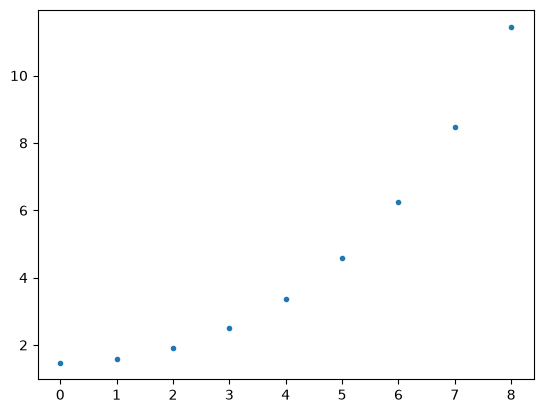

In [28]:
plt.plot(pp,'.')


In [29]:
np.log10(2)

np.float64(0.3010299956639812)

In [30]:
np.log(2)

np.float64(0.6931471805599453)

In [31]:
df["Edot_tot"].to_numpy().reshape(8,9,9)[:,:,:]

array([[[ 8.90756560e-02,  7.92126358e-02,  4.87213052e-02,
          3.11785366e-02,  2.34783125e-02,  2.03751351e-02,
          1.91628546e-02,  1.86948936e-02,  1.85150805e-02],
        [ 8.74178768e-02,  8.01176992e-02,  5.24004721e-02,
          2.34640737e-02, -3.47958121e-02, -1.41743641e-01,
         -2.29824265e-02, -9.58965775e-02, -7.57672860e-02],
        [ 8.66401539e-02,  7.90209210e-02,  5.10615676e-02,
         -4.21291886e-02, -5.92592889e-02,  3.37133613e-02,
          3.35225115e-02,  3.33806450e-02,  3.32464852e-02],
        [ 8.62632430e-02,  7.60796148e-02, -5.61668578e-03,
          3.92403700e-02,  3.56266811e-02,  3.46542922e-02,
          3.44261934e-02,  3.43715032e-02,  3.43579083e-02],
        [ 8.61666628e-02,  4.06434743e-02, -6.48419655e-01,
          3.92521717e-02, -1.07601608e-01, -5.26585127e-02,
         -2.14277144e+00, -1.28812420e-02, -1.60379146e+00],
        [ 8.61791420e-02,  7.09384969e-02,  5.01318347e-02,
         -2.19759532e-01, -6.660632